# Model Development Notebook
This notebook covers the full end-to-end machine learning pipeline for the Hospital Management System, including data inspection, EDA, feature engineering, modeling, evaluation, tuning, and serialization.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading
Loading the synthetic raw data generated for the HMS.

In [2]:
appointments_df = pd.read_csv('../data/raw/appointments.csv')
admissions_df = pd.read_csv('../data/raw/admissions.csv')
patients_df = pd.read_csv('../data/raw/patients.csv')

## 2. Data Inspection
Inspecting shape, info, head, null values, duplicates, and general descriptions.

In [3]:
# Checking shapes
print("Appointments Shape:", appointments_df.shape)
print("Admissions Shape:", admissions_df.shape)
print("Patients Shape:", patients_df.shape)

Appointments Shape: (2000, 5)
Admissions Shape: (1000, 4)
Patients Shape: (1000, 4)


In [4]:
# Checking info
print(appointments_df.info())
print("\n", admissions_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   appointment_id  2000 non-null   object
 1   patient_id      2000 non-null   object
 2   department      2000 non-null   object
 3   date            2000 non-null   object
 4   no_show         2000 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 78.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   admission_id          1000 non-null   object
 1   patient_id            1000 non-null   object
 2   ward                  1000 non-null   object
 3   length_of_stay_hours  1000 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 31.4+ KB

 None


In [5]:
# Head of data
display(appointments_df.head())
display(admissions_df.head())

,appointment_id,patient_id,department,date,no_show
0,A00001,P00982,neurology,2025-02-12 08:00:00,0
1,A00002,P00526,pediatrics,2025-09-27 14:00:00,0
2,A00003,P00455,neurology,2025-03-27 22:00:00,0
3,A00004,P00741,pediatrics,2025-06-30 01:00:00,1
4,A00005,P00598,pediatrics,2025-05-26 16:00:00,0


,admission_id,patient_id,ward,length_of_stay_hours
0,ADM00001,P00045,emergency,460
1,ADM00002,P00777,emergency,230
2,ADM00003,P00998,emergency,72
3,ADM00004,P00774,icu,567
4,ADM00005,P00819,general,705


In [6]:
# Duplicates and Null values
print("Appointments Duplicates:", appointments_df.duplicated().sum())
print("Appointments Nulls:\n", appointments_df.isnull().sum())
print("\nAdmissions Duplicates:", admissions_df.duplicated().sum())
print("Admissions Nulls:\n", admissions_df.isnull().sum())

Appointments Duplicates: 0
Appointments Nulls:
 appointment_id    0
patient_id        0
department        0
date              0
no_show           0
dtype: int64

Admissions Duplicates: 0
Admissions Nulls:
 admission_id            0
patient_id              0
ward                    0
length_of_stay_hours    0
dtype: int64


In [7]:
# Descriptive statistics
display(appointments_df.describe())
display(admissions_df.describe())

,no_show
count,2000.000000
mean,0.194500
std,0.395914
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


,length_of_stay_hours
count,1000.000000
mean,366.635000
std,200.588448
min,25.000000
25%,194.750000
50%,354.000000
75%,540.250000
max,719.000000


## 3. Exploratory Data Analysis (EDA)
Visualizing distributions, class imbalances, and outliers.

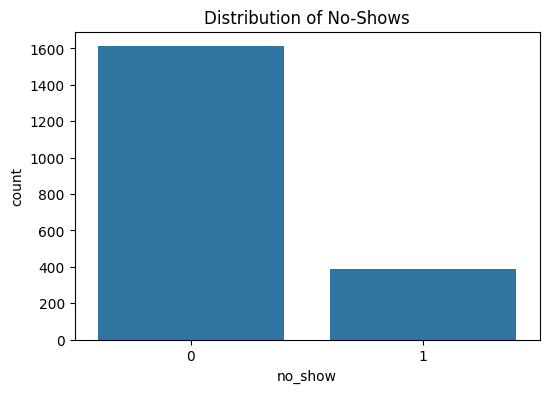

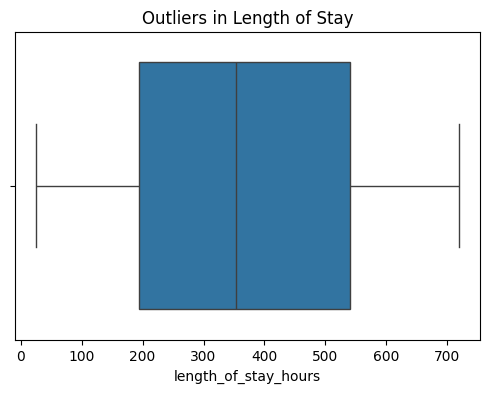

In [8]:
# Target imbalance check for No-Shows
plt.figure(figsize=(6,4))
sns.countplot(data=appointments_df, x='no_show')
plt.title('Distribution of No-Shows')
plt.show()

# Boxplot for outliers in length of stay
plt.figure(figsize=(6,4))
sns.boxplot(data=admissions_df, x='length_of_stay_hours')
plt.title('Outliers in Length of Stay')
plt.show()

## 4. Feature Engineering
Encoding categorical features for modeling.

In [9]:
# Department encoding
appointments_df['department_code'] = appointments_df['department'].astype('category').cat.codes
# Ward encoding
admissions_df['ward_code'] = admissions_df['ward'].astype('category').cat.codes

print("Categorical Encoding Completed.")

Categorical Encoding Completed.


## 5. Modeling: Patient No-Show Prediction
Using a classification model to predict missed appointments.

Accuracy: 0.7975

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89       319
           1       0.00      0.00      0.00        81

    accuracy                           0.80       400
   macro avg       0.40      0.50      0.44       400
weighted avg       0.64      0.80      0.71       400



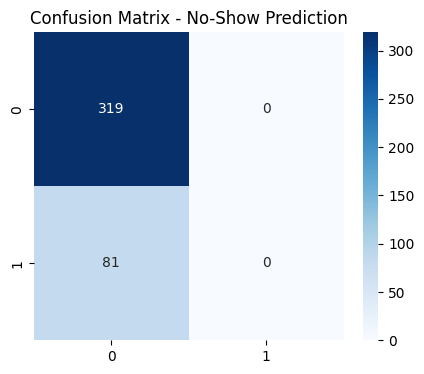

In [10]:
x_ns = appointments_df[['department_code']]
y_ns = appointments_df['no_show']

# Dataset split
x_train_ns, x_test_ns, y_train_ns, y_test_ns = train_test_split(x_ns, y_ns, test_size=0.2, random_state=42)

# Train
rf_classifier = RandomForestClassifier(n_estimators=50, random_state=42)
rf_classifier.fit(x_train_ns, y_train_ns)

# Evaluate
preds_ns = rf_classifier.predict(x_test_ns)
print(f"Accuracy: {accuracy_score(y_test_ns, preds_ns):.4f}")
print("\nClassification Report:\n", classification_report(y_test_ns, preds_ns))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_ns, preds_ns), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - No-Show Prediction')
plt.show()

### Tuning & Validation (No-Show)

In [11]:
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
grid_search_ns = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search_ns.fit(x_train_ns, y_train_ns)
best_rf_clf = grid_search_ns.best_estimator_
print("Best Params:", grid_search_ns.best_params_)
print("Tuned Accuracy:", accuracy_score(y_test_ns, best_rf_clf.predict(x_test_ns)))

Best Params: {'max_depth': None, 'n_estimators': 50}
Tuned Accuracy: 0.7975


### Feature Importance (No-Show)

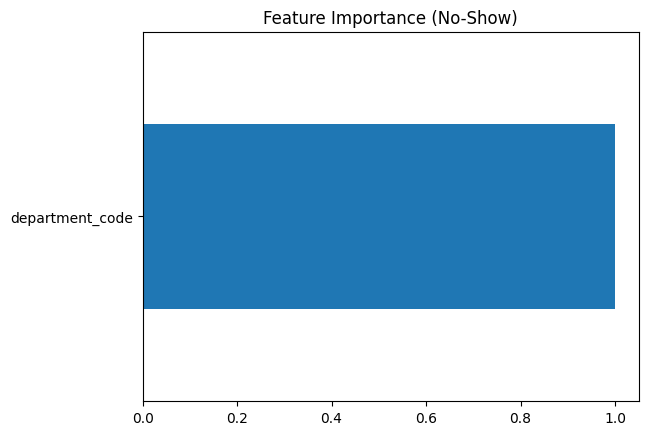

In [12]:
pd.Series(best_rf_clf.feature_importances_, index=x_ns.columns).plot(kind='barh')
plt.title('Feature Importance (No-Show)')
plt.show()

## 6. Modeling: Bed Occupancy Prediction
Using a regression model to forecast lengths of stay.

In [13]:
x_occ = admissions_df[['ward_code']]
y_occ = admissions_df['length_of_stay_hours']

# Split
x_train_occ, x_test_occ, y_train_occ, y_test_occ = train_test_split(x_occ, y_occ, test_size=0.2, random_state=42)

# Train
rf_regressor = RandomForestRegressor(n_estimators=50, random_state=42)
rf_regressor.fit(x_train_occ, y_train_occ)

# Evaluate
preds_occ = rf_regressor.predict(x_test_occ)
print(f"MSE: {mean_squared_error(y_test_occ, preds_occ):.4f}")
print(f"R2 Score: {r2_score(y_test_occ, preds_occ):.4f}")

MSE: 37936.2215
R2 Score: -0.0228


### Tuning & Validation (Occupancy)

In [14]:
grid_search_occ = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_squared_error')
grid_search_occ.fit(x_train_occ, y_train_occ)
best_rf_reg = grid_search_occ.best_estimator_
print("Best Params:", grid_search_occ.best_params_)
print("Tuned MSE:", mean_squared_error(y_test_occ, best_rf_reg.predict(x_test_occ)))

Best Params: {'max_depth': None, 'n_estimators': 100}
Tuned MSE: 37985.256947785405


## 7. Final Model Serialization
Saving the best tuned models for production inference.

In [15]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_rf_clf, '../models/no_show_rf.pkl')
joblib.dump(best_rf_reg, '../models/occupancy_rf.pkl')
print("Models successfully serialized to models/ folder.")

Models successfully serialized to models/ folder.
